# Spam SMS Detection

Classify SMS messages as **spam** or **legitimate (ham)** using TF-IDF features with Naive Bayes, Logistic Regression, and SVM classifiers.

**Dataset:** SMS Spam Collection — 5,572 labeled messages (`ham`/`spam`).

In [1]:
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Load & Clean Data

The raw CSV carries 3 junk columns (a handful of messages contain stray commas that spill
into `Unnamed: 2/3/4`). We only need the label and the message text. We also drop exact
duplicate rows — the raw file has 403 of them, which would otherwise let identical messages
leak between train and test splits.

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)
print(f"Loaded {n_before} rows -> {n_after} after removing {n_before - n_after} exact duplicates")

df['label_num'] = (df['label'] == 'spam').astype(int)
df.head()

Loaded 5572 rows -> 5169 after removing 403 exact duplicates


In [3]:
print(df['label'].value_counts())
baseline_acc = (df['label'] == 'ham').mean()
print(f"\nBaseline accuracy (always predict 'ham'): {baseline_acc:.4f}")

label
ham     4516
spam     653
Name: count, dtype: int64

Baseline accuracy (always predict 'ham'): 0.8737


> **Why this matters:** with ~87% of messages being `ham`, a model that never predicts
> spam at all would still be "87% accurate." Accuracy alone is a misleading metric on
> imbalanced data like this — **precision, recall, and F1 on the spam class** are what
> actually indicate whether the model catches spam without burying real messages in false
> positives. Every model below is judged on those, not raw accuracy.

## 2. Exploratory Data Analysis

Spam messages tend to be noticeably longer than ham messages (they're often promotional
copy stuffed with a call to action, a phone number, or a link).

In [4]:
df['msg_length'] = df['message'].apply(len)
print(df.groupby('label')['msg_length'].mean())

label
ham      70.459256
spam    137.891271
Name: msg_length, dtype: float64


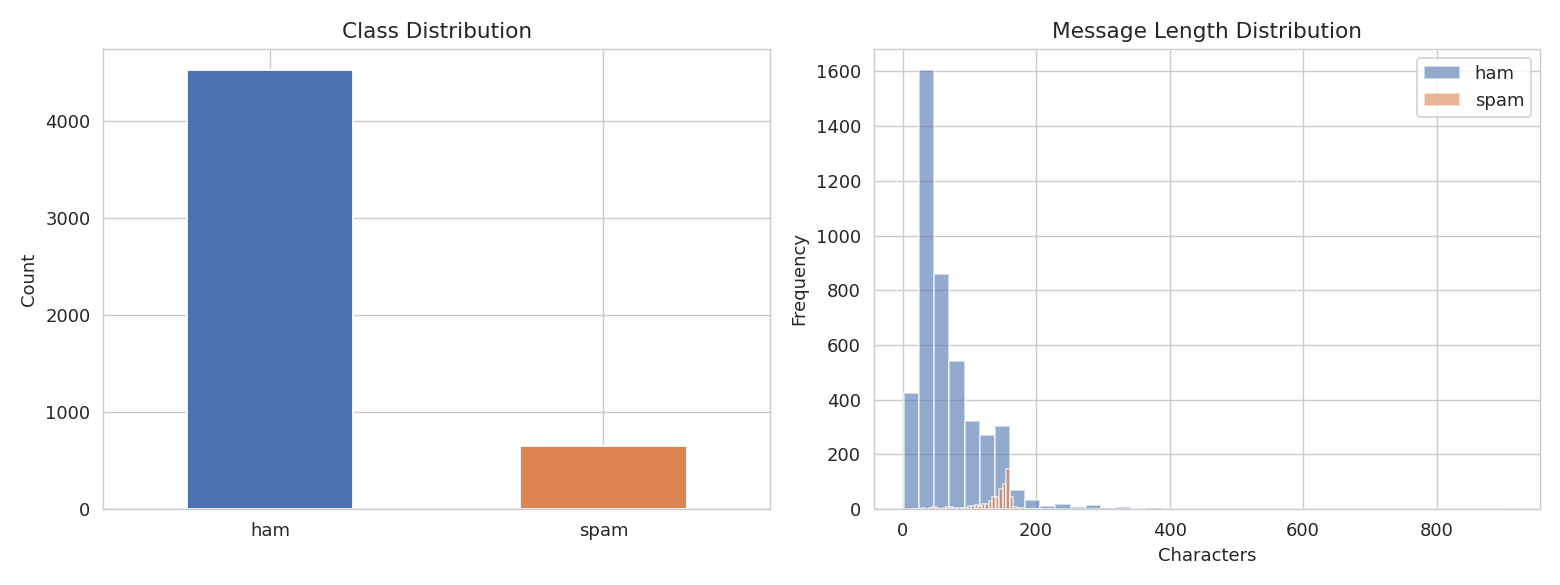

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Distribution')
axes[0].tick_params(axis='x', rotation=0)

for label, color in zip(['ham', 'spam'], ['#4C72B0', '#DD8452']):
    axes[1].hist(df[df['label'] == label]['msg_length'], bins=40, alpha=0.6, label=label, color=color)
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Text Preprocessing

Lowercase, strip emails/URLs/punctuation/digits, and drop stopwords. A manual stopword
list is used instead of `nltk` so this notebook runs anywhere with no extra downloads.

In [6]:
STOPWORDS = set("""
a about above after again against all am an and any are aren't as at be
because been before being below between both but by can't cannot could
couldn't did didn't do does doesn't doing don't down during each few for
from further had hadn't has hasn't have haven't having he he'd he'll he's
her here here's hers herself him himself his how how's i i'd i'll i'm i've
if in into is isn't it it's its itself let's me more most mustn't my myself
no nor not of off on once only or other ought our ours ourselves out over
own same shan't she she'd she'll she's should shouldn't so some such than
that that's the their theirs them themselves then there there's these they
they'd they'll they're they've this those through to too under until up
very was wasn't we we'd we'll we're we've were weren't what what's when
when's where where's which while who who's whom why why's with won't would
wouldn't you you'd you'll you're you've your yours yourself yourselves
""".split())

def clean_text(text: str) -> str:
    """Lowercase, strip punctuation/digits, drop stopwords."""
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', ' ', text)
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
print("RAW  :", df['message'].iloc[2])
print("CLEAN:", df['clean_message'].iloc[2])

RAW  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
CLEAN: free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply


## 4. Train/Test Split + TF-IDF Vectorization

80/20 stratified split so the spam ratio is preserved in both sets. TF-IDF with unigrams
+ bigrams, capped at 3,000 features.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'], df['label_num'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df['label_num']
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"TF-IDF feature count: {X_train_tfidf.shape[1]}")

Train size: 4135, Test size: 1034
TF-IDF feature count: 3000


## 5. Train & Evaluate Models

Three classifiers, all on the same TF-IDF features: **Multinomial Naive Bayes**,
**Logistic Regression**, and a **linear SVM**. `class_weight='balanced'` is used on
LR/SVM to counter the class imbalance.

In [8]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM (Linear)": LinearSVC(class_weight='balanced'),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})
    fitted_models[name] = (model, preds)

    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['ham', 'spam']))

--- Naive Bayes ---
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.98      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.97      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

--- Logistic Regression ---
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       903
        spam       0.89      0.91      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.94      1034
weighted avg       0.98      0.97      0.97      1034

--- SVM (Linear) ---
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.91      0.89      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.94      0.94      1034
weigh

In [9]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df

                Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.974855   0.894737  0.908397  0.901515
1          SVM (Linear)  0.973888   0.906250  0.885496  0.895753
2           Naive Bayes  0.968085   0.980392  0.763359  0.858369

**Naive Bayes** has the highest *precision* (98%) — when it flags something as spam,
it's almost always right — but its *recall* is only 76%, meaning it quietly lets ~1 in 4
spam messages through as "ham". **Logistic Regression** and **SVM** trade a little precision
for much better recall, catching more spam overall with only a small increase in false
positives. For a spam filter, missed spam (false negative) is usually more costly than an
occasional legitimate message getting flagged, so **Logistic Regression** — highest F1 and
best balance — is picked as the final model.

## 6. Confusion Matrices

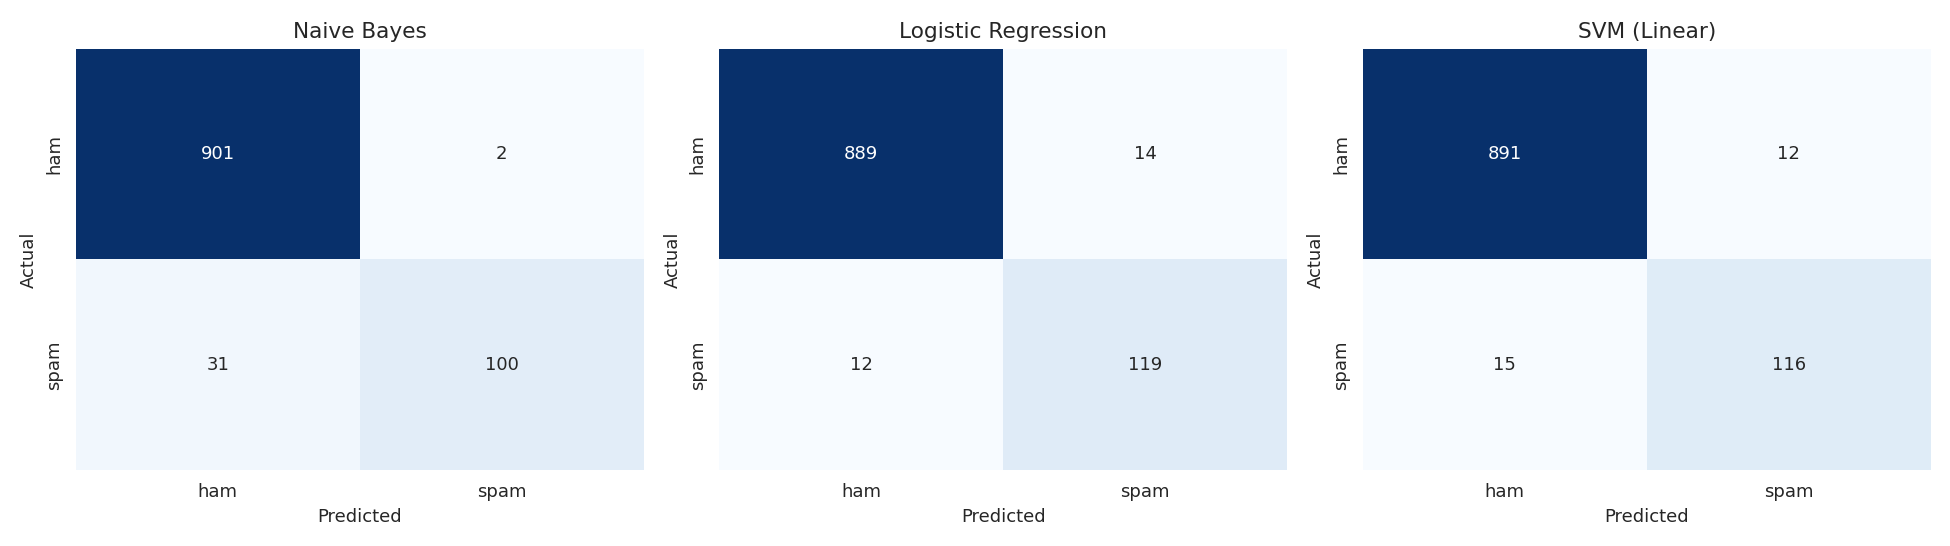

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, (model, preds)) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'], cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

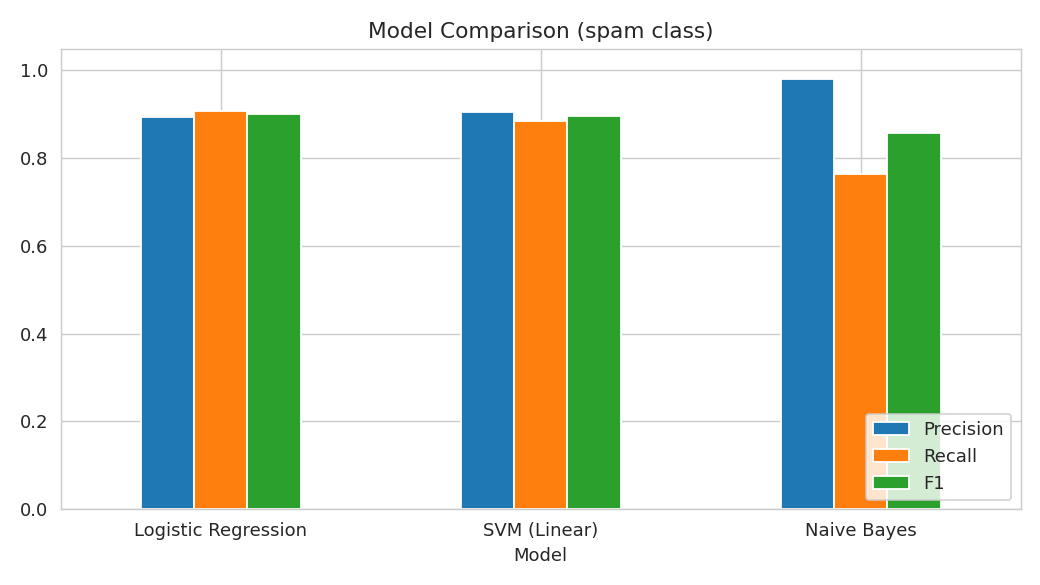

In [11]:
results_df.set_index('Model')[['Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(8, 4.5))
plt.title('Model Comparison (spam class)')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Save the Best Model

Vectorizer and classifier are saved as two separate files (rather than one bundled
pipeline) so `test_custom_input.py` can load them independently.

In [12]:
best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name][0]
print(f"Best model by F1: {best_name}")

joblib.dump(best_model, 'spam_classifier_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Saved spam_classifier_model.pkl and tfidf_vectorizer.pkl")

test_messages = df.loc[X_test.index, 'message']
best_preds = fitted_models[best_name][1]
predictions_df = pd.DataFrame({
    'message': test_messages.values,
    'actual_label': y_test.map({0: 'ham', 1: 'spam'}).values,
    'predicted_label': pd.Series(best_preds).map({0: 'ham', 1: 'spam'}).values
})
predictions_df['correct'] = predictions_df['actual_label'] == predictions_df['predicted_label']
predictions_df.to_csv('predictions.csv', index=False)
print(f"Saved predictions.csv ({len(predictions_df)} rows, {predictions_df['correct'].mean():.2%} correct)")

Best model by F1: Logistic Regression
Saved spam_classifier_model.pkl and tfidf_vectorizer.pkl
Saved predictions.csv (1034 rows, 97.49% correct)


## 8. Try It

In [13]:
def predict_message(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    return 'spam' if pred == 1 else 'ham'

demo_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your mobile number has won 2000 pounds. Call 09061701461 to claim.",
    "Can you send me the notes from today's class?"
]

for msg in demo_messages:
    print(f"[{predict_message(msg):>4}] {msg}")

[spam] Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!
[ ham] Hey, are we still meeting for lunch tomorrow?
[spam] URGENT! Your mobile number has won 2000 pounds. Call 09061701461 to claim.
[ ham] Can you send me the notes from today's class?


## Summary

- Removed 403 duplicate rows before splitting to avoid train/test leakage.
- Compared three classifiers on identical TF-IDF features (unigrams + bigrams, 3,000 features).
- **Logistic Regression** won on F1 (0.90), balancing precision (0.89) and recall (0.91) on the spam class — beating both SVM (F1 0.896) and Naive Bayes (F1 0.858, high precision but weak recall).
- Judged models on spam-class precision/recall/F1, not raw accuracy, since ~87% of the data is `ham` and accuracy alone would hide a model that misses most spam.
- Final model (`spam_classifier_model.pkl`) and vectorizer (`tfidf_vectorizer.pkl`) are saved separately for use in `test_custom_input.py`.